# Deep Learning Applications

#### **Author:** Lila Nguyen
#### **Date:** October 7, 2025

In [82]:
# imports
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
from tensorflow.keras.callbacks import EarlyStopping
import time
from sklearn.preprocessing import StandardScaler

## Part 1 - Analyzing Student Academic Trends
**Goal:** Apply deep learning techniques to predict final exam scores based on lifestyle and academic features of students.

In [49]:
# load in data
student_fn = os.path.join(os.getcwd(), os.pardir, 'data', 'student_exam_scores.csv')
student_df = pd.read_csv(student_fn)

# inspect data
print(student_df.shape, '\n')
print(student_df.dtypes, '\n')
student_df.head()

(200, 6) 

student_id             object
hours_studied         float64
sleep_hours           float64
attendance_percent    float64
previous_scores         int64
exam_score            float64
dtype: object 



,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [50]:
# check for missing data
student_df.isna().sum()

student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

**Defining the Label:**
The goal of this ML problem is to predict student final exam scores, so the label will be the `exam_score` column.

**Identifying the Features:** 
`student_id` is unlikely to contribute meaningful predictive power, so this feature is excluded. The features will be the remaining columns in the dataset, and a correlation matrix will be computed to determine if any of these features should be dropped.

In [51]:
# drop 'student_id'
student_df.drop(columns='student_id', inplace=True)

In [52]:
# don't need to observe correlation of label with itself
exclude = ['exam_score']

# compute correlations of all features with our label 
corrs = student_df.corr()['exam_score'].drop(exclude, axis=0).sort_values(ascending=False)
corrs

hours_studied         0.776751
previous_scores       0.431105
attendance_percent    0.225713
sleep_hours           0.188222
Name: exam_score, dtype: float64

From the computed correlations of the remaining features with `exam_score`:
* `hours_studied` has the **strongest** correlation
* `previous_scores` have a **moderate** correlation
* `attendance_percent` has a **weak to moderate** correlation
* `sleep_hours` has a **weak** correlation

In [53]:
# identify features
student_features = list(student_df.drop(columns='exam_score', axis=1).columns)
student_features

['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']

In [54]:
# create labeled examples
X = student_df[student_features]
y = student_df['exam_score']

In [55]:
# create training and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4)
print(X_train.shape)
print(X_test.shape)

(140, 4)
(60, 4)


In [56]:
# construct the neural network
# create model object
score_nn = keras.Sequential()

# create input layer and add it to model object
input_layer = keras.layers.InputLayer(input_shape=(X_train.shape[1],))
score_nn.add(input_layer)

# create the hidden layers and add them to the model object
hl_1 = keras.layers.Dense(units=64, activation='relu', name='hl_1')
hl_2 = keras.layers.Dense(units=32, activation='relu', name='hl_2')
hl_3 = keras.layers.Dense(units=16, activation='relu', name='hl_3')

score_nn.add(hl_1)
score_nn.add(hl_2)
score_nn.add(hl_3)

# create output layer and add it to model object
output_layer = keras.layers.Dense(units=1, activation='linear', name='output')
score_nn.add(output_layer)

# get summary of neural network model structure
score_nn.summary()

# compile model
score_nn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005), 
                 loss='mse', 
                 metrics=['mae']
                )

/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hl_1 (Dense)                    │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hl_2 (Dense)                    │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hl_3 (Dense)                    │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# custom logger function (outputs every 50 epochs)
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))

In [58]:
# create early stopping callback
early_stop = EarlyStopping(monitor='val_loss',
                           patience=15,          
                           restore_best_weights=True
                          )

In [59]:
# fit model to training data
t0 = time.time() # start
num_epochs = 100 

history = score_nn.fit(
    X_train,
    y_train,
    epochs=num_epochs,
    verbose=0,
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5), early_stop],
    validation_data=(X_test, y_test)
)

t1 = time.time() # stop

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 100], Loss: 57.7786, Mae: 5.9609, Val_loss: 39.7813, Val_mae: 5.3448
Epoch [10/ 100], Loss: 41.9369, Mae: 5.1416, Val_loss: 33.1508, Val_mae: 4.9359
Epoch [15/ 100], Loss: 35.5122, Mae: 4.7895, Val_loss: 25.9854, Val_mae: 4.1592
Epoch [20/ 100], Loss: 32.3773, Mae: 4.5909, Val_loss: 25.2967, Val_mae: 4.1288
Epoch [25/ 100], Loss: 30.4116, Mae: 4.4679, Val_loss: 22.9487, Val_mae: 3.8369
Epoch [30/ 100], Loss: 28.8520, Mae: 4.3624, Val_loss: 22.2197, Val_mae: 3.7629
Epoch [35/ 100], Loss: 27.5879, Mae: 4.2600, Val_loss: 21.8986, Val_mae: 3.7247
Epoch [40/ 100], Loss: 26.2261, Mae: 4.1567, Val_loss: 21.0022, Val_mae: 3.6662
Epoch [45/ 100], Loss: 24.4381, Mae: 4.0057, Val_loss: 19.0056, Val_mae: 3.4769
Epoch [50/ 100], Loss: 23.0133, Mae: 3.8816, Val_loss: 17.9393, Val_mae: 3.3850
Epoch [55/ 100], Loss: 20.9989, Mae: 3.7063, Val_loss: 16.4625, Val_mae: 3.2432
Epoch [60/ 100], Loss: 19.3947, Mae: 3.5495, Val_loss: 15.0187, Val_mae: 3.1014
Epoch [65/ 100], Loss: 17.1233, Mae: 3.35

* Validation mean absolute error converged around 2.35
* So on average, predictions fall ±2.35 points within the actual exam scores

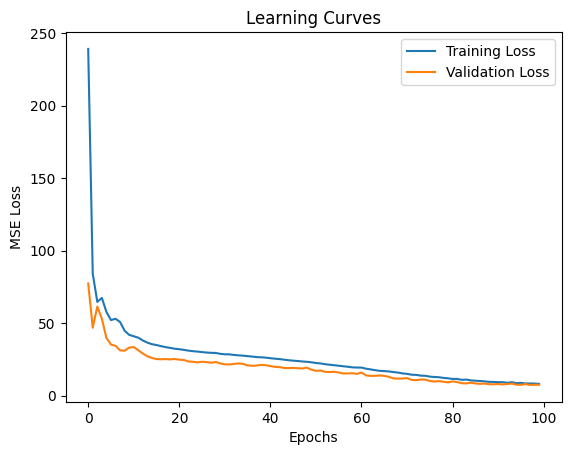

In [63]:
# visualize what's happening
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Learning Curves')
plt.show()

In [60]:
loss, accuracy = score_nn.evaluate(X_test, y_test, verbose=0)
print('Loss: ', str(loss) , 'Accuracy: ', str(accuracy))

Loss:  7.403110980987549 Accuracy:  2.333371877670288


* A loss of 7.40 and mean absolute error of 2.33 indicates good model fit
* Training loss and validation loss are decreasing together, which indicates that the model is learning the patterns in the data well.
* There are no signs of overfitting. The neural network seems to generalize well to unseen student data, as indicated by how both curves converge similarly around epoch 80-100.

## Part 2 - Lifestyle and Sleep Patterns
**Goal:** Design and train a deep learning model to classify individuals as having a sleep disorder or not, based on lifestyle and physiological data. Explore how features like stress level, BMI, heart rate, and physical activity correlate with sleep health.

In [69]:
# load in data
sleep_fn = os.path.join(os.getcwd(), os.pardir, 'data', 'Sleep_health_and_lifestyle_dataset.csv')
sleep_df = pd.read_csv(sleep_fn)

# inspect data
print(sleep_df.shape, '\n')
print(sleep_df.dtypes, '\n')
sleep_df.head()

(374, 13) 

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object 



,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [70]:
# check for missing data
sleep_df.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

There is a large percentage of missing data in the label, so these rows will be dropped.

**Defining the Label:**
The goal of this ML problem is to classify individuals as having a sleep disorder or not, so our label will be the `Sleep Disorder` column. This label will have to be converted to numeric first.

**Identifying the Features:** 
`Person ID` is unlikely to contribute meaningful predictive power, so this feature is excluded. Our features will be the remaining columns in the dataset. For the remaining numerical features, a correlation matrix will be computed to determine if any of them should be dropped. For the categorical features (i.e. `Gender`, `Occupation`, `BMI Category`), we'll perform one-hot encoding first.

In [71]:
# drop missing data in label
sleep_df.dropna(subset=['Sleep Disorder'], inplace=True)

# check for potential class imbalance
print(sleep_df['Sleep Disorder'].value_counts())

# drop 'Person ID'
sleep_df.drop(columns='Person ID', inplace=True)

Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64


In [72]:
# convert label to numeric
sleep_df['Sleep Disorder'] = sleep_df['Sleep Disorder'].apply(lambda x: 0 if x == 'None' else 1)

# perform one-hot encoding
sleep_df = pd.get_dummies(sleep_df, 
                          columns=['Gender', 'Occupation', 'BMI Category'], 
                          drop_first=True
                         )

bp_split = sleep_df['Blood Pressure'].str.split('/', expand=True).astype(float)
bp_split.columns = ['Systolic', 'Diastolic']
sleep_df = pd.concat([sleep_df.drop(columns='Blood Pressure'), bp_split], axis=1)

In [74]:
# create labeled examples
X = sleep_df.drop(columns='Sleep Disorder')
y = sleep_df['Sleep Disorder']

In [78]:
# create training and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4)
print(X_train.shape)
print(X_test.shape)

(108, 22)
(47, 22)


In [83]:
# scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [87]:
# construct the neural network
# create model object
sleep_nn = keras.Sequential()

# create input layer and add it to model object
input_layer = keras.layers.InputLayer(input_shape=(X_train.shape[1],))
sleep_nn.add(input_layer)

# create the hidden layers with L2 regularization and add them to the model object
hl_1 = keras.layers.Dense(units=64, activation='relu', name='hl_1')
hl_2 = keras.layers.Dense(units=32, activation='relu', name='hl_2')
hl_3 = keras.layers.Dense(units=16, activation='relu', name='hl_3')

sleep_nn.add(hl_1)
sleep_nn.add(hl_2)
sleep_nn.add(hl_3)

# create output layer and add it to model object
output_layer = keras.layers.Dense(units=1, activation='sigmoid', name='output')
sleep_nn.add(output_layer)

# get summary of neural network model structure
sleep_nn.summary()

# define optimization algorithm
adam_optimizer = keras.optimizers.Adam()

# define loss function
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

# compile model
sleep_nn.compile(optimizer=adam_optimizer, loss=loss_fn, metrics=['accuracy'])

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hl_1 (Dense)                    │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hl_2 (Dense)                    │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hl_3 (Dense)                    │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
# train model
history = sleep_nn.fit(X_train, 
                       y_train,
                       validation_data=(X_test, y_test),
                       epochs=100,
                       batch_size=16,
                       verbose=1
                      )

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.5370 - loss: 1.0618 - val_accuracy: 0.5957 - val_loss: 0.9995
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5556 - loss: 0.9257 - val_accuracy: 0.5957 - val_loss: 0.8836
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5648 - loss: 0.8268 - val_accuracy: 0.5957 - val_loss: 0.8101
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5648 - loss: 0.7634 - val_accuracy: 0.5957 - val_loss: 0.7337
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5648 - loss: 0.6975 - val_accuracy: 0.6170 - val_loss: 0.6829
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6574 - loss: 0.6530 - val_accuracy: 0.8085 - val_loss: 0.6368
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7870 - loss: 0.6129 - val_accuracy: 0.8085 - val_loss: 0.5899
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7870 - loss: 0.5638 - val_accuracy: 0.8085 - val_loss:

In [89]:
# evaluate model
loss, accuracy = sleep_nn.evaluate(X_test, y_test, verbose=0)
print('Loss: ', str(loss) , 'Accuracy: ', str(accuracy))

Loss:  0.0006237364723347127 Accuracy:  1.0


In [90]:
# make predictions on test data
pred_probs = sleep_nn.predict(X_test)
pred_classes = (pred_probs >= 0.5).astype(int)

print(np.concatenate([pred_probs[:10], pred_classes[:10]], axis=1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[0.99997652 1.        ]
 [0.99961507 1.        ]
 [0.99998522 1.        ]
 [0.99997008 1.        ]
 [0.99999499 1.        ]
 [0.99997556 1.        ]
 [0.99955291 1.        ]
 [1.         1.        ]
 [0.99680883 1.        ]
 [0.99972862 1.        ]]


## Part 3 - Healthy Eating
**Goal:** Build a deep learning model to predict whether a meal is healthy based on its nutritional profile and categorical attributes.

In [15]:
# load in data
healthy_fn = os.path.join(os.getcwd(), os.pardir, 'data', 'healthy_eating_dataset.csv')
healthy_df = pd.read_csv(healthy_fn)

# inspect data
print(healthy_df.shape, '\n')
print(healthy_df.dtypes, '\n')
healthy_df.head()

(2000, 20) 

meal_id             int64
meal_name          object
cuisine            object
meal_type          object
diet_type          object
calories            int64
protein_g         float64
carbs_g           float64
fat_g             float64
fiber_g           float64
sugar_g           float64
sodium_mg           int64
cholesterol_mg      int64
serving_size_g      int64
cooking_method     object
prep_time_min       int64
cook_time_min       int64
rating            float64
is_healthy          int64
image_url          object
dtype: object 



,meal_id,meal_name,cuisine,meal_type,diet_type,calories,protein_g,carbs_g,fat_g,fiber_g,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,cooking_method,prep_time_min,cook_time_min,rating,is_healthy,image_url
0,1,Kid Pasta,Indian,Lunch,Keto,737,52.4,43.9,34.3,16.8,42.9,2079,91,206,Grilled,47,56,4.4,0,https://example.com/images/meal_1.jpg
1,2,Husband Rice,Mexican,Lunch,Paleo,182,74.7,144.4,0.1,22.3,38.6,423,7,317,Roasted,51,34,2.4,0,https://example.com/images/meal_2.jpg
2,3,Activity Rice,Indian,Snack,Paleo,881,52.9,97.3,18.8,20.0,37.5,2383,209,395,Boiled,58,29,4.3,0,https://example.com/images/meal_3.jpg
3,4,Another Salad,Mexican,Snack,Keto,427,17.5,73.1,7.6,9.8,41.7,846,107,499,Grilled,14,81,4.6,0,https://example.com/images/meal_4.jpg
4,5,Quite Stew,Thai,Lunch,Vegan,210,51.6,104.3,26.3,24.8,18.2,1460,42,486,Raw,47,105,4.3,0,https://example.com/images/meal_5.jpg


In [16]:
# check for missing data
healthy_df.isna().sum()

meal_id           0
meal_name         0
cuisine           0
meal_type         0
diet_type         0
calories          0
protein_g         0
carbs_g           0
fat_g             0
fiber_g           0
sugar_g           0
sodium_mg         0
cholesterol_mg    0
serving_size_g    0
cooking_method    0
prep_time_min     0
cook_time_min     0
rating            0
is_healthy        0
image_url         0
dtype: int64